# Resolution Comparison Experiment on COVIDx Dataset

This notebook explores the performance impact of image resolution on a Deep Learning model (ResNet18). We compare:
1. **Original Resolution Images**
2. **256x256 Resized Images**

This version uses the modular functions from the `functions` directory.

## 1. Setup and Configuration

In this section, we import the necessary libraries, configure the device, and add the `functions` path to the system path.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt

# Add functions directory to path
sys.path.append(os.path.abspath('functions'))

from train import train
from evaluation import plot_results, eval_on_metrics
from dataset import COVIDxResolutionDataset

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Paths
ROOT_DIR = '/home/furkan/Documents'
CSV_PATH = '/home/furkan/Documents/covidx/covidx_merged.csv'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

criterion = nn.CrossEntropyLoss()

os.makedirs('logs',exist_ok=True)
os.makedirs('models',exist_ok=True)

Using device: cuda


## 2. Scenario 1: Original Resolution Training

Training on original images using the imported `train` function.

[2026_03_03_23_15_49] Training started.


Training Original Resolution Model...


Epoch 1/5 - Validation: 100%|██████████| 265/265 [00:37<00:00,  7.15it/s]
[2026_03_03_23_20_50] Epoch [1/5]
[2026_03_03_23_20_50]   Train Loss: 0.1007, Train Acc: 0.9719
[2026_03_03_23_20_50]   Val   Loss: 0.1823, Val   Acc: 0.9462
[2026_03_03_23_20_50]   Best model saved with val_loss: 0.1823


Epoch [1/5]
  Train Loss: 0.1007, Train Acc: 0.9719
  Val   Loss: 0.1823, Val   Acc: 0.9462
  Best model saved with val_loss: 0.1823


Epoch 2/5 - Validation: 100%|██████████| 265/265 [00:37<00:00,  7.15it/s]
[2026_03_03_23_25_51] Epoch [2/5]
[2026_03_03_23_25_51]   Train Loss: 0.0659, Train Acc: 0.9822
[2026_03_03_23_25_51]   Val   Loss: 0.2054, Val   Acc: 0.9441
[2026_03_03_23_25_51]   No improvement. Early stopping counter: 1/3


...

Epoch [3/5]
  Train Loss: 0.0526, Train Acc: 0.9846
  Val   Loss: 0.2126, Val   Acc: 0.9524
  No improvement. Early stopping counter: 2/3


Epoch 4/5 - Validation: 100%|██████████| 265/265 [00:37<00:00,  7.05it/s]
[2026_03_03_23_36_10] Epoch [4/5]
[2026_03_03_23_36_10]   Train Loss: 0.0400, Train Acc: 0.9871
[2026_03_03_23_36_10]   Val   Loss: 0.2074, Val   Acc: 0.9533
[2026_03_03_23_36_10]   No improvement. Early stopping counter: 3/3
[2026_03_03_23_36_10]   Early stopping triggered. Training stopped.
[2026_03_03_23_36_10] 
========== BEST MODEL SUMMARY ==========
[2026_03_03_23_36_10] Best Epoch      : 1
[2026_03_03_23_36_10] Val Loss        : 0.1823
[2026_03_03_23_36_10] ========================================


Epoch [4/5]
  Train Loss: 0.0400, Train Acc: 0.9871
  Val   Loss: 0.2074, Val   Acc: 0.9533
  No improvement. Early stopping counter: 3/3
  Early stopping triggered. Training stopped.

========== BEST MODEL SUMMARY ==========
Best Epoch      : 1
Val Loss        : 0.1823

Evaluation on Test Data (Original):


Evaluating: 100%|██████████| 266/266 [00:37<00:00,  7.03it/s]


Accuracy:  0.5396
Precision: 0.5210
Recall:    0.9818
F1 Score:  0.6808
AUC:       0.6989


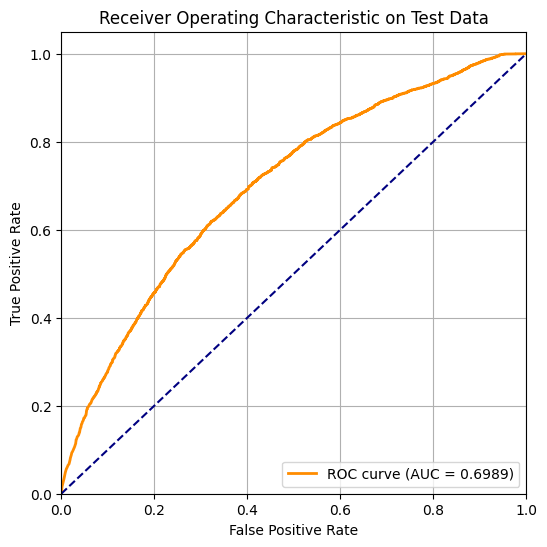

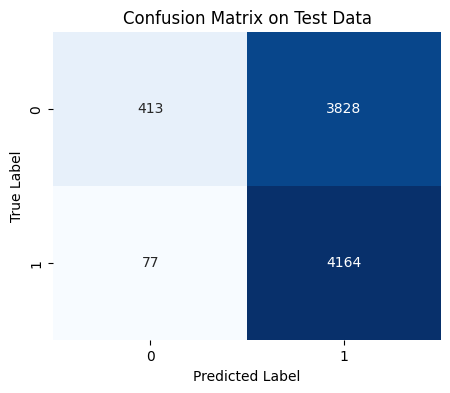

In [2]:

train_ds_orig = COVIDxResolutionDataset(CSV_PATH, ROOT_DIR, split='train', transform=transform, use_resized=False)
val_ds_orig = COVIDxResolutionDataset(CSV_PATH, ROOT_DIR, split='val', transform=transform, use_resized=False)
test_ds_orig = COVIDxResolutionDataset(CSV_PATH, ROOT_DIR, split='test', transform=transform, use_resized=False)

train_loader_orig = DataLoader(train_ds_orig, batch_size=32, shuffle=True, num_workers=4)
val_loader_orig = DataLoader(val_ds_orig, batch_size=32, shuffle=False, num_workers=4)
test_loader_orig = DataLoader(test_ds_orig, batch_size=32, shuffle=False, num_workers=4)

model_orig = models.resnet18(weights='DEFAULT')
model_orig.fc = nn.Linear(model_orig.fc.in_features, 2)

optimizer = optim.Adam(model_orig.parameters(), lr=0.0001)

print("Training Original Resolution Model...")
logs_orig = train(
    model=model_orig, 
    train_loader=train_loader_orig, 
    val_loader=val_loader_orig, 
    criterion=criterion, 
    optimizer=optimizer, 
    device=device, 
    save_path='models/best_model_orig.pth', 
    num_epochs=5, 
    patience=3, 
    log_path='logs/training_orig.log'
)

print("\nEvaluation on Test Data (Original):")
eval_on_metrics(model_orig, test_loader_orig)

## 3. Scenario 2: 256x256 Resized Training

Training on resized images using the same imported `train` function.

[2026_03_03_23_36_49] Training started.


Training 256x256 Resized Model...


Epoch 1/5 - Validation: 100%|██████████| 265/265 [00:08<00:00, 32.73it/s]
[2026_03_03_23_39_44] Epoch [1/5]
[2026_03_03_23_39_44]   Train Loss: 0.0963, Train Acc: 0.9739
[2026_03_03_23_39_44]   Val   Loss: 0.2013, Val   Acc: 0.9476
[2026_03_03_23_39_44]   Best model saved with val_loss: 0.2013


Epoch [1/5]
  Train Loss: 0.0963, Train Acc: 0.9739
  Val   Loss: 0.2013, Val   Acc: 0.9476
  Best model saved with val_loss: 0.2013


Epoch 2/5 - Validation: 100%|██████████| 265/265 [00:07<00:00, 36.49it/s]
[2026_03_03_23_42_40] Epoch [2/5]
[2026_03_03_23_42_40]   Train Loss: 0.0640, Train Acc: 0.9826
[2026_03_03_23_42_40]   Val   Loss: 0.1750, Val   Acc: 0.9528
[2026_03_03_23_42_40]   Best model saved with val_loss: 0.1750


...

Epoch [4/5]
  Train Loss: 0.0388, Train Acc: 0.9878
  Val   Loss: 0.2268, Val   Acc: 0.9516
  No improvement. Early stopping counter: 1/3


Epoch 5/5 - Validation: 100%|██████████| 265/265 [00:06<00:00, 38.67it/s]
[2026_03_03_23_50_41] Epoch [5/5]
[2026_03_03_23_50_41]   Train Loss: 0.0272, Train Acc: 0.9906
[2026_03_03_23_50_41]   Val   Loss: 0.2773, Val   Acc: 0.9523
[2026_03_03_23_50_41]   No improvement. Early stopping counter: 2/3
[2026_03_03_23_50_41] 
========== BEST MODEL SUMMARY ==========
[2026_03_03_23_50_41] Best Epoch      : 3
[2026_03_03_23_50_41] Val Loss        : 0.1745
[2026_03_03_23_50_41] ========================================


Epoch [5/5]
  Train Loss: 0.0272, Train Acc: 0.9906
  Val   Loss: 0.2773, Val   Acc: 0.9523
  No improvement. Early stopping counter: 2/3

========== BEST MODEL SUMMARY ==========
Best Epoch      : 3
Val Loss        : 0.1745

Evaluation on Test Data (Resized):


Evaluating: 100%|██████████| 266/266 [00:08<00:00, 29.82it/s]


Accuracy:  0.5275
Precision: 0.5142
Recall:    0.9974
F1 Score:  0.6785
AUC:       0.6899


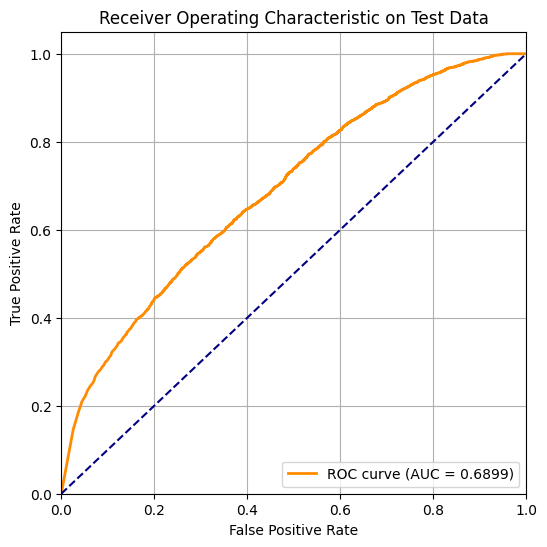

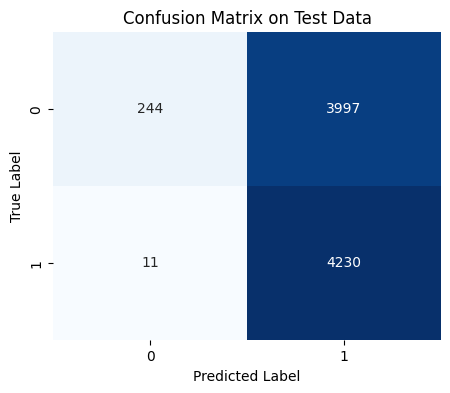

In [3]:
train_ds_res = COVIDxResolutionDataset(CSV_PATH, ROOT_DIR, split='train', transform=transform, use_resized=True)
val_ds_res = COVIDxResolutionDataset(CSV_PATH, ROOT_DIR, split='val', transform=transform, use_resized=True)
test_ds_res = COVIDxResolutionDataset(CSV_PATH, ROOT_DIR, split='test', transform=transform, use_resized=True)

train_loader_res = DataLoader(train_ds_res, batch_size=32, shuffle=True, num_workers=4)
val_loader_res = DataLoader(val_ds_res, batch_size=32, shuffle=False, num_workers=4)
test_loader_res = DataLoader(test_ds_res, batch_size=32, shuffle=False, num_workers=4)

model_res = models.resnet18(weights='DEFAULT')
model_res.fc = nn.Linear(model_res.fc.in_features, 2)

optimizer_res = optim.Adam(model_res.parameters(), lr=0.0001)

print("Training 256x256 Resized Model...")
logs_res = train(
    model=model_res, 
    train_loader=train_loader_res, 
    val_loader=val_loader_res, 
    criterion=criterion, 
    optimizer=optimizer_res, 
    device=device, 
    save_path='models/best_model_res.pth', 
    num_epochs=5, 
    patience=3, 
    log_path='logs/training_res.log'
)

print("\nEvaluation on Test Data (Resized):")
eval_on_metrics(model_res, test_loader_res)

## 4. Comparison of Results

Visualizing the training history using `plot_results`.

Original Resolution curves:


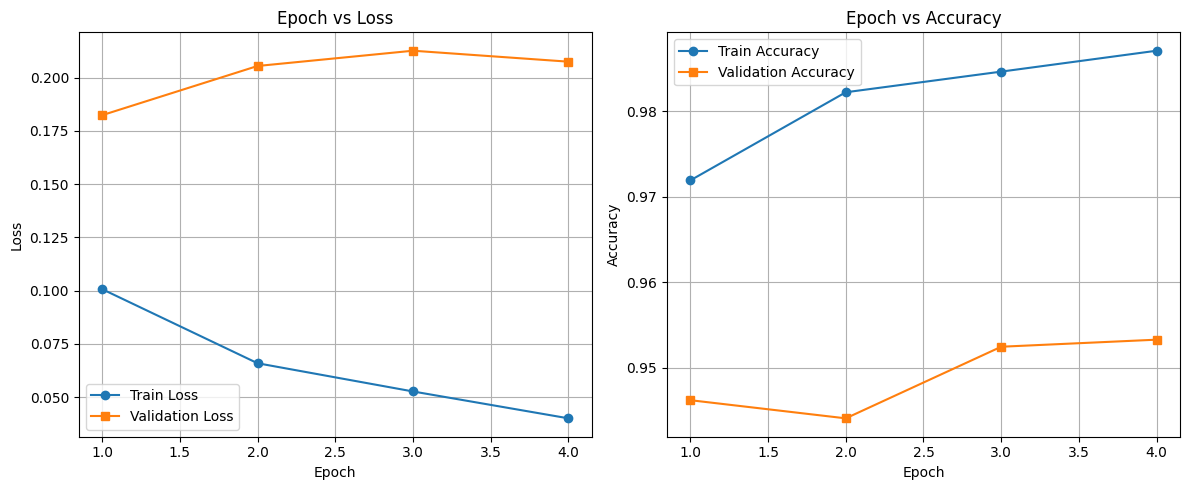

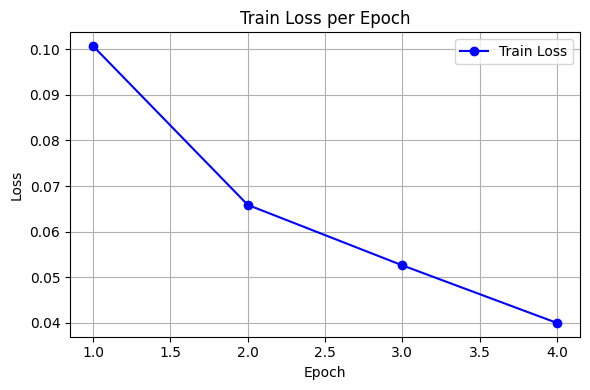

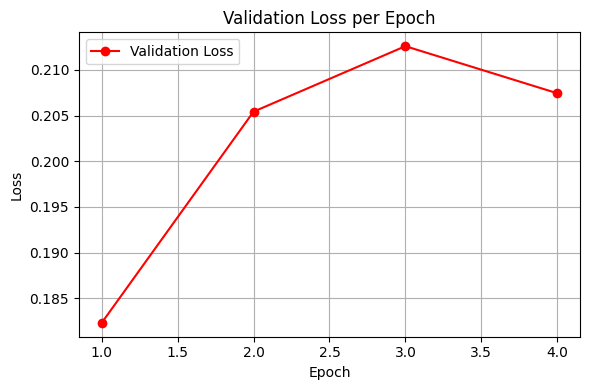

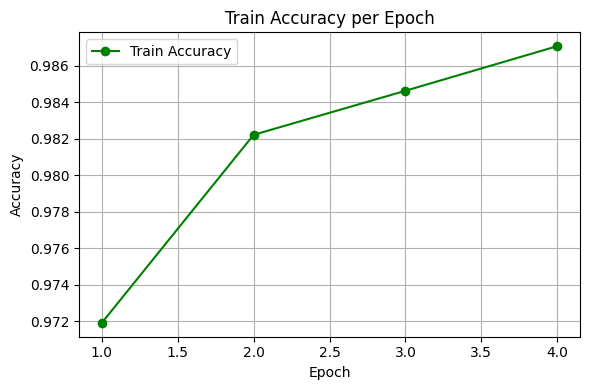

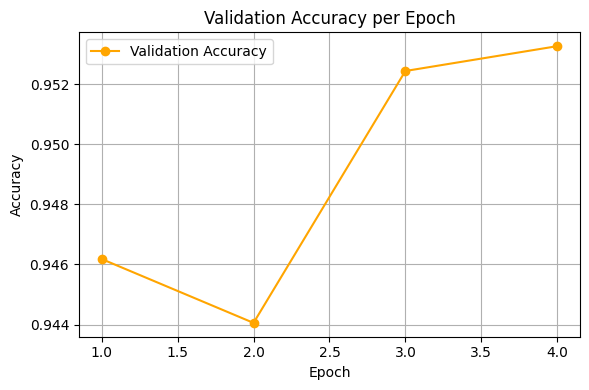


256x256 Resolution curves:


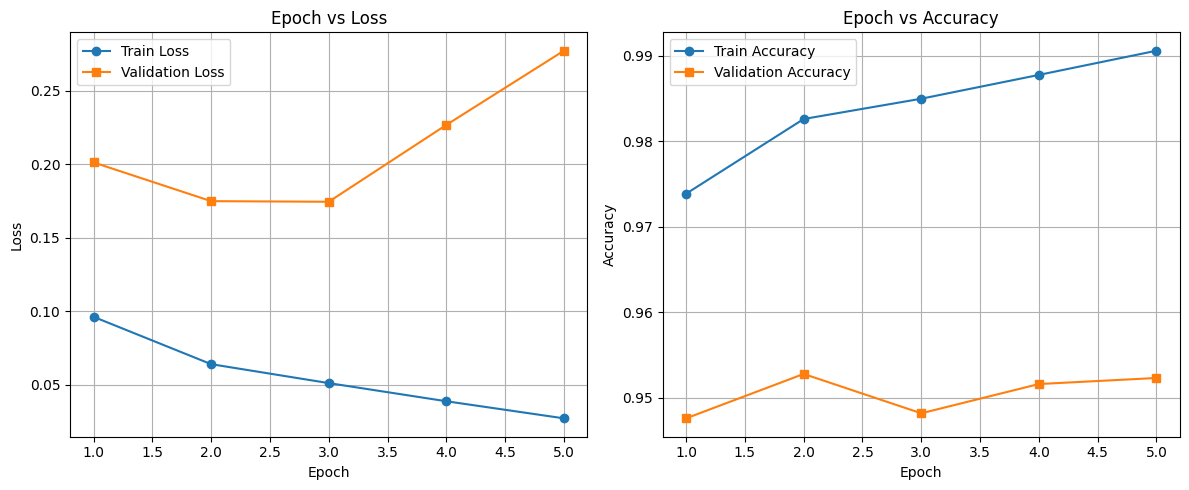

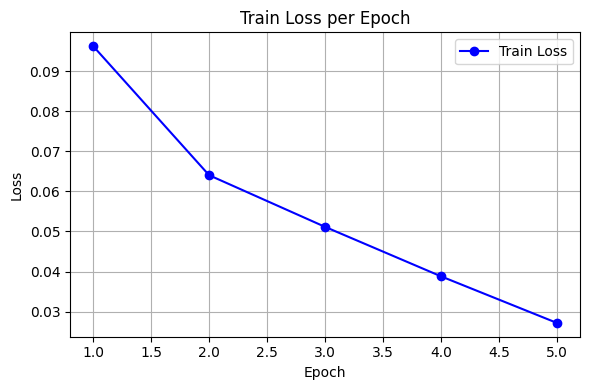

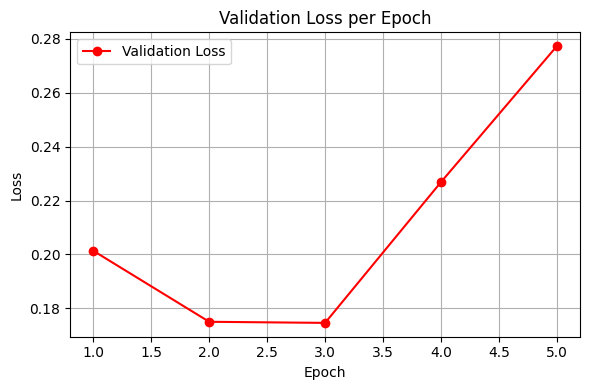

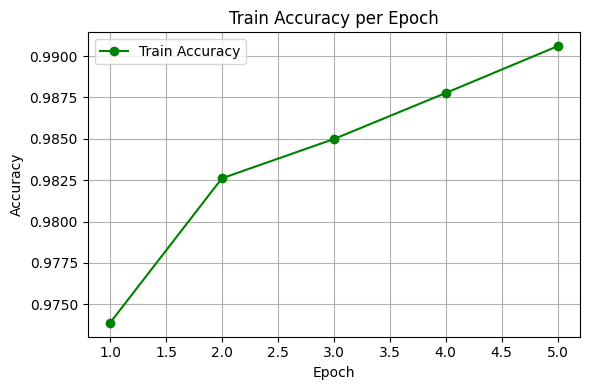

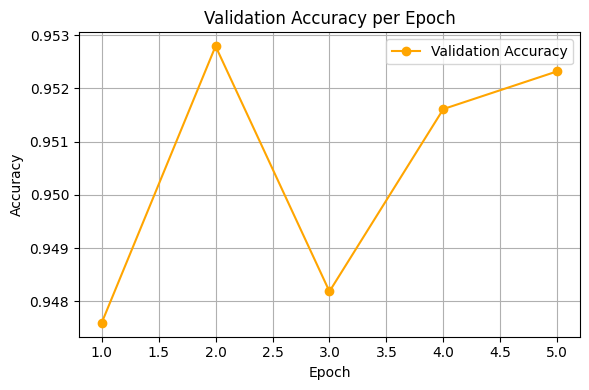

In [4]:
print("Original Resolution curves:")
plot_results(*logs_orig)

print("\n256x256 Resolution curves:")
plot_results(*logs_res)